# CarDD — детекция повреждений автомобиля: RT-DETR (свой тренировочный цикл)

Вторая из двух моделей (первая — YOLOv8 через `ultralytics`). Здесь **свой** тренировочный цикл поверх `RTDetrForObjectDetection` из
Hugging Face `transformers`.

**Модель — `PekingU/rtdetr_r18vd`**


## 1. Установка и импорты

In [1]:
!pip install transformers ensemble-boxes torchmetrics --quiet

In [2]:
import os
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import RTDetrForObjectDetection, RTDetrImageProcessor
from ensemble_boxes import weighted_boxes_fusion
from torchmetrics.detection.mean_ap import MeanAveragePrecision

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [3]:
RANDOM_STATE = 20
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", DEVICE)

DATA_DIR = "/kaggle/input/datasets/gabrielfcarvalho/cardd-with-yolo-annotations-images-labels"
CHECKPOINT = "PekingU/rtdetr_r18vd"

CLASS_NAMES = ["dent", "scratch", "crack", "glass shatter", "lamp broken", "tire flat"]
NUM_CLASSES = len(CLASS_NAMES)

EPOCHS = 60
BATCH_SIZE = 8
LR = 1e-4
WEIGHT_DECAY = 1e-4
EARLY_STOP_PATIENCE = 15

Устройство: cuda


## 2. Модель и image processor

`RTDetrImageProcessor` делает всю нормализацию/ресайз изображения (модель
рассчитана на вход 640×640)


In [4]:
image_processor = RTDetrImageProcessor.from_pretrained(CHECKPOINT)

model = RTDetrForObjectDetection.from_pretrained(
    CHECKPOINT,
    num_labels=NUM_CLASSES,
    id2label=dict(enumerate(CLASS_NAMES)),
    label2id={name: i for i, name in enumerate(CLASS_NAMES)},
    ignore_mismatched_sizes=True,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Всего параметров: {n_params:,}")

preprocessor_config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/80.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

RTDetrForObjectDetection LOAD REPORT from: PekingU/rtdetr_r18vd
Key                                        | Status   |                                                                                      
-------------------------------------------+----------+--------------------------------------------------------------------------------------
model.denoising_class_embed.weight         | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([81, 256]) vs model:torch.Size([7, 256])
model.decoder.class_embed.{0, 1, 2}.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([80]) vs model:torch.Size([6])          
model.decoder.class_embed.{0, 1, 2}.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([80, 256]) vs model:torch.Size([6, 256])
model.enc_score_head.bias                  | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([80]) vs model:torch.Size([6])          
model.enc_score_head.weight                | MISMATCH | Reinit due to size mismatch 

Всего параметров: 20,079,592


## 3. Dataset — конвертация YOLO-разметки в формат, который ждёт image processor

YOLO-формат: `class_id, x_center, y_center, width, height`, все нормировано
на [0,1]

Нужен COCO-стиль: `[x_min, y_min, width, height]` в абсолютных пикселях, привязанный к `image_id`.


In [5]:
class CarDDDetectionDataset(Dataset):
    def __init__(self, images_dir, labels_dir, image_processor, class_names):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.image_processor = image_processor
        self.class_names = class_names
        self.image_files = sorted(os.listdir(images_dir))

    def __len__(self):
        return len(self.image_files)

    def _load_yolo_as_coco(self, label_path, img_w, img_h, image_id):
        annotations = []
        if os.path.exists(label_path):
            with open(label_path) as f:
                for ann_id, line in enumerate(f):
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cls_id, xc, yc, w, h = parts
                    cls_id = int(cls_id)
                    xc, yc, w, h = float(xc) * img_w, float(yc) * img_h, float(w) * img_w, float(h) * img_h
                    x_min, y_min = xc - w / 2, yc - h / 2
                    annotations.append({
                        "id": ann_id, "image_id": image_id, "category_id": cls_id,
                        "bbox": [x_min, y_min, w, h], "area": w * h, "iscrowd": 0,
                    })
        return annotations

    def __getitem__(self, idx):
        fname = self.image_files[idx]
        image = Image.open(f"{self.images_dir}/{fname}").convert("RGB")
        img_w, img_h = image.size

        label_path = f"{self.labels_dir}/{fname.rsplit('.', 1)[0]}.txt"
        annotations = self._load_yolo_as_coco(label_path, img_w, img_h, image_id=idx)

        target = {"image_id": idx, "annotations": annotations}
        encoding = self.image_processor(images=image, annotations=target, return_tensors="pt")

        pixel_values = encoding["pixel_values"][0]
        labels = encoding["labels"][0]
        return pixel_values, labels, fname, (img_w, img_h)


def collate_fn(batch):
    pixel_values = torch.stack([item[0] for item in batch])
    labels = [item[1] for item in batch]
    filenames = [item[2] for item in batch]
    sizes = [item[3] for item in batch]
    return pixel_values, labels, filenames, sizes

In [6]:
train_dataset = CarDDDetectionDataset(f"{DATA_DIR}/train/images", f"{DATA_DIR}/train/labels", image_processor, CLASS_NAMES)
val_dataset = CarDDDetectionDataset(f"{DATA_DIR}/val/images", f"{DATA_DIR}/val/labels", image_processor, CLASS_NAMES)
test_dataset = CarDDDetectionDataset(f"{DATA_DIR}/test/images", f"{DATA_DIR}/test/labels", image_processor, CLASS_NAMES)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2)

print("Батчей на эпоху (train):", len(train_loader))

Батчей на эпоху (train): 352


## 4. Функции train/eval

`outputs.loss` — уже готовый, посчитанный моделью композитный лосс (Hungarian
matching + классификация + L1 + GIoU)

поэтому остается обычный цикл вокруг этого: обнулить градиенты, посчитать forward, сделать backward, шаг оптимизатора


In [7]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    n_samples = 0
    for pixel_values, labels, _, _ in tqdm(loader, desc="train", leave=False):
        pixel_values = pixel_values.to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in labels]

        optimizer.zero_grad()
        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * pixel_values.size(0)
        n_samples += pixel_values.size(0)
    return total_loss / n_samples


@torch.no_grad()
def evaluate_loss(model, loader, device):
    model.eval()
    total_loss = 0.0
    n_samples = 0
    for pixel_values, labels, _, _ in tqdm(loader, desc="eval", leave=False):
        pixel_values = pixel_values.to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in labels]
        outputs = model(pixel_values=pixel_values, labels=labels)
        total_loss += outputs.loss.item() * pixel_values.size(0)
        n_samples += pixel_values.size(0)
    return total_loss / n_samples


def plot_history(history):
    hist_df = pd.DataFrame(history)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(hist_df["epoch"], hist_df["train_loss"], label="train", marker="o")
    ax.plot(hist_df["epoch"], hist_df["val_loss"], label="val", marker="o")
    ax.set_title(f"Loss (эпоха {hist_df['epoch'].iloc[-1]})")
    ax.set_xlabel("Эпоха")
    ax.legend()
    plt.show()


## 5. Цикл обучения

train:   0%|          | 0/352 [00:00<?, ?it/s]

eval:   0%|          | 0/102 [00:00<?, ?it/s]

Эпоха 1/60 (271 сек) | train loss 74.7832 | val loss 33.5743


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  -> новый лучший чекпоинт (val loss = 33.5743)


...

train:   0%|          | 0/352 [00:00<?, ?it/s]

eval:   0%|          | 0/102 [00:00<?, ?it/s]

Эпоха 5/60 (324 сек) | train loss 17.1288 | val loss 10.3222


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  -> новый лучший чекпоинт (val loss = 10.3222)


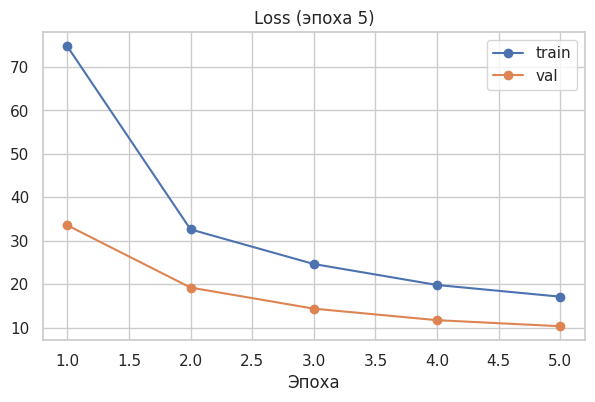

train:   0%|          | 0/352 [00:00<?, ?it/s]

eval:   0%|          | 0/102 [00:00<?, ?it/s]

Эпоха 6/60 (263 сек) | train loss 15.5159 | val loss 9.8075


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  -> новый лучший чекпоинт (val loss = 9.8075)


...

train:   0%|          | 0/352 [00:00<?, ?it/s]

eval:   0%|          | 0/102 [00:00<?, ?it/s]

Эпоха 10/60 (263 сек) | train loss 12.3521 | val loss 8.5375


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  -> новый лучший чекпоинт (val loss = 8.5375)


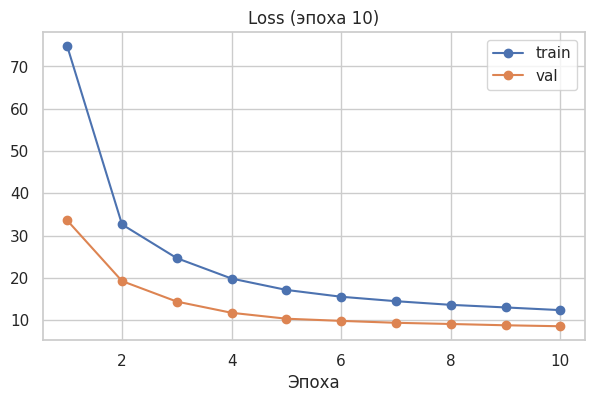

train:   0%|          | 0/352 [00:00<?, ?it/s]

eval:   0%|          | 0/102 [00:00<?, ?it/s]

Эпоха 11/60 (262 сек) | train loss 11.7934 | val loss 8.5526


train:   0%|          | 0/352 [00:00<?, ?it/s]

eval:   0%|          | 0/102 [00:00<?, ?it/s]

...

Эпоха 13/60 (262 сек) | train loss 10.7844 | val loss 8.4993


train:   0%|          | 0/352 [00:00<?, ?it/s]

eval:   0%|          | 0/102 [00:00<?, ?it/s]

eval:   0%|          | 0/102 [00:00<?, ?it/s]

Эпоха 15/60 (265 сек) | train loss 9.8981 | val loss 8.3714


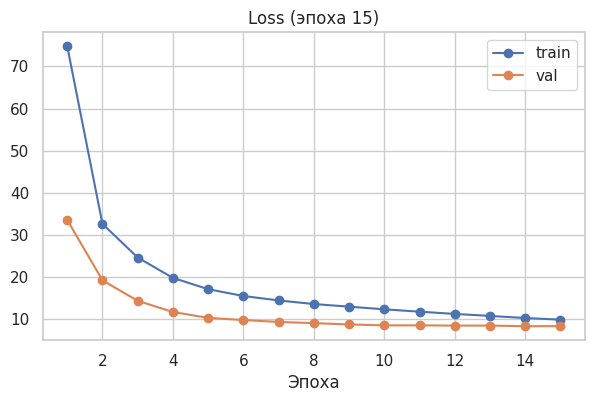

train:   0%|          | 0/352 [00:00<?, ?it/s]

eval:   0%|          | 0/102 [00:00<?, ?it/s]

Эпоха 16/60 (262 сек) | train loss 9.4367 | val loss 8.3300


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  -> новый лучший чекпоинт (val loss = 8.3300)


...

eval:   0%|          | 0/102 [00:00<?, ?it/s]

Эпоха 19/60 (263 сек) | train loss 8.3956 | val loss 8.4863


train:   0%|          | 0/352 [00:00<?, ?it/s]

eval:   0%|          | 0/102 [00:00<?, ?it/s]

Эпоха 20/60 (272 сек) | train loss 8.1175 | val loss 8.5504


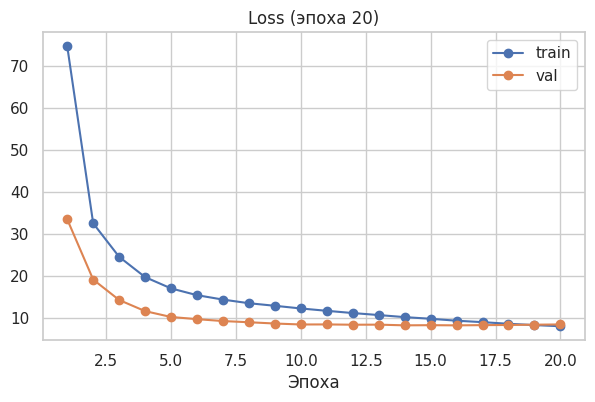

train:   0%|          | 0/352 [00:00<?, ?it/s]

eval:   0%|          | 0/102 [00:00<?, ?it/s]

Эпоха 21/60 (263 сек) | train loss 7.8992 | val loss 8.5016


train:   0%|          | 0/352 [00:00<?, ?it/s]

eval:   0%|          | 0/102 [00:00<?, ?it/s]

...

eval:   0%|          | 0/102 [00:00<?, ?it/s]

Эпоха 24/60 (272 сек) | train loss 7.2309 | val loss 8.5732


train:   0%|          | 0/352 [00:00<?, ?it/s]

eval:   0%|          | 0/102 [00:00<?, ?it/s]

Эпоха 25/60 (272 сек) | train loss 7.1236 | val loss 8.5906


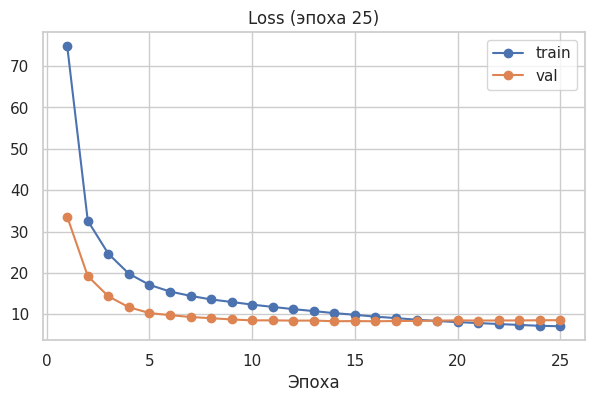

train:   0%|          | 0/352 [00:00<?, ?it/s]

eval:   0%|          | 0/102 [00:00<?, ?it/s]

Эпоха 26/60 (413 сек) | train loss 6.9695 | val loss 8.6660


train:   0%|          | 0/352 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ae76d141b20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ae76d141b20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

eval:   0%|          | 0/102 [00:00<?, ?it/s]

Эпоха 29/60 (272 сек) | train loss 6.5026 | val loss 8.7471


train:   0%|          | 0/352 [00:00<?, ?it/s]

eval:   0%|          | 0/102 [00:00<?, ?it/s]

Эпоха 30/60 (261 сек) | train loss 6.3557 | val loss 8.7744


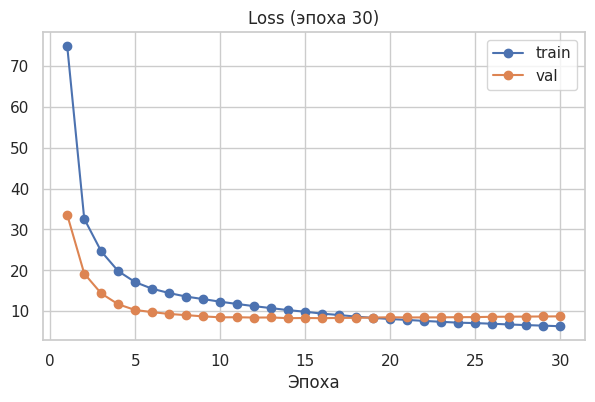

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ae76d141b20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    <function _MultiProcessingDataLoaderIter.__del__ at 0x7ae76d141b20>if w.is_alive():

 Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
       self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^if w.is_alive():^
 ^ ^ ^ ^ ^^ ^ ^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^^
  ^^   

train:   0%|          | 0/352 [00:00<?, ?it/s]

^ ^ ^  ^
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
 ^    assert self._parent_pid == os.getpid(), 'can only test a child process'^
 ^^  ^^^^  ^ ^ ^ ^  ^ ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
^AssertionError^: ^can only test a child process^
^^^^^^^^^^
AssertionError: can only test a child process


KeyboardInterrupt: 

In [8]:
import math

LR = 2e-5
WARMUP_EPOCHS = 5

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

history = []
best_val_loss = float("inf")
epochs_without_improvement = 0
CHECKPOINT_PATH = "/kaggle/working/rtdetr_r18vd_best"

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
    val_loss = evaluate_loss(model, val_loader, DEVICE)
    scheduler.step()

    elapsed = time.time() - start_time
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "seconds": elapsed})

    print(f"Эпоха {epoch}/{EPOCHS} ({elapsed:.0f} сек) | train loss {train_loss:.4f} | val loss {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        model.save_pretrained(CHECKPOINT_PATH)
        print(f"  -> новый лучший чекпоинт (val loss = {val_loss:.4f})")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOP_PATIENCE:
            print(f"  -> нет улучшений {EARLY_STOP_PATIENCE} эпох подряд, останавливаемся раньше")
            break

    if epoch % 5 == 0:
        plot_history(history)

plot_history(history)
pd.DataFrame(history).to_csv("/kaggle/working/rtdetr_history.csv", index=False)

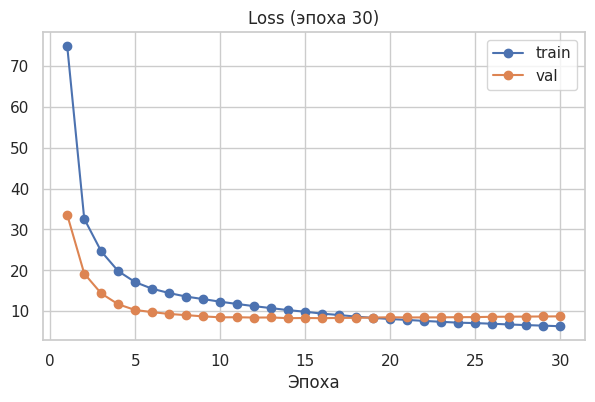

In [9]:
plot_history(history)
pd.DataFrame(history).to_csv("/kaggle/working/rtdetr_history.csv", index=False)

обучение прервано, потому что по графику и по результатам видно переобучение

## 6. Загрузка лучшего чекпоинт

In [26]:
best_model = RTDetrForObjectDetection.from_pretrained(CHECKPOINT_PATH).to(DEVICE)
best_model.eval()
print("Лучший чекпоинт загружен")

Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

Лучший чекпоинт загружен


## 7. Пост-обработка предсказаний, приведение к тому же формату, что YOLOv8

`post_process_object_detection` переводит сырой выход модели в
координаты абсолютных пикселей исходного изображения, дальше деление на
ширину/высоту, чтобы получить нормированные `xyxy`


In [27]:
@torch.no_grad()
def extract_predictions(model, loader, image_processor, conf_threshold=0.001):
    predictions = {}
    for pixel_values, _, filenames, sizes in tqdm(loader, desc="predict", leave=False):
        pixel_values = pixel_values.to(DEVICE)
        outputs = model(pixel_values=pixel_values)

        target_sizes = torch.tensor([(h, w) for w, h in sizes]).to(DEVICE)
        results = image_processor.post_process_object_detection(
            outputs, target_sizes=target_sizes, threshold=conf_threshold
        )

        for fname, result, (img_w, img_h) in zip(filenames, results, sizes):
            boxes = result["boxes"].cpu().numpy()
            boxes_norm = boxes / np.array([img_w, img_h, img_w, img_h])
            predictions[fname] = {
                "boxes": boxes_norm.tolist(),
                "scores": result["scores"].cpu().numpy().tolist(),
                "labels": result["labels"].cpu().numpy().astype(int).tolist(),
            }
    return predictions


val_preds_plain = extract_predictions(best_model, val_loader, image_processor)
test_preds_plain = extract_predictions(best_model, test_loader, image_processor)
print(f"Предсказания (без TTA): val={len(val_preds_plain)}, test={len(test_preds_plain)}")

predict:   0%|          | 0/102 [00:00<?, ?it/s]

predict:   0%|          | 0/47 [00:00<?, ?it/s]

Предсказания (без TTA): val=810, test=374


## 8. TTA — горизонтальный флип + WBF-слияние с оригиналом

прогон каждого изображения еще
раз в отраженном виде, переворот предсказанных координат рамок
обратно в исходную ориентацию, и объединение с обычными предсказаниями
через WBF (равные веса 0.5/0.5)

In [30]:
@torch.no_grad()
def extract_predictions_flipped(model, image_dir, image_processor, conf_threshold=0.001):
    predictions = {}
    for fname in sorted(os.listdir(image_dir)):
        image = Image.open(f"{image_dir}/{fname}").convert("RGB")
        img_w, img_h = image.size
        flipped = image.transpose(Image.FLIP_LEFT_RIGHT)

        inputs = image_processor(images=flipped, return_tensors="pt").to(DEVICE)
        outputs = model(**inputs)
        result = image_processor.post_process_object_detection(
            outputs, target_sizes=torch.tensor([(img_h, img_w)]).to(DEVICE), threshold=conf_threshold
        )[0]

        boxes = result["boxes"].cpu().numpy()
        boxes_unflipped = boxes.copy()
        boxes_unflipped[:, 0] = img_w - boxes[:, 2]
        boxes_unflipped[:, 2] = img_w - boxes[:, 0]
        boxes_norm = boxes_unflipped / np.array([img_w, img_h, img_w, img_h])

        predictions[fname] = {
            "boxes": boxes_norm.tolist(),
            "scores": result["scores"].cpu().numpy().tolist(),
            "labels": result["labels"].cpu().numpy().astype(int).tolist(),
        }
    return predictions


def merge_tta(preds_plain, preds_flipped, image_files):
    fused = {}
    for fname in image_files:
        p1, p2 = preds_plain[fname], preds_flipped[fname]
        if len(p1["boxes"]) == 0 and len(p2["boxes"]) == 0:
            fused[fname] = {"boxes": [], "scores": [], "labels": []}
            continue
        if len(p1["boxes"]) == 0:
            fused[fname] = p2
            continue
        if len(p2["boxes"]) == 0:
            fused[fname] = p1
            continue

        boxes, scores, labels = weighted_boxes_fusion(
            [p1["boxes"], p2["boxes"]], [p1["scores"], p2["scores"]], [p1["labels"], p2["labels"]],
            weights=[1, 1], iou_thr=0.5, skip_box_thr=0.0001,
        )
        fused[fname] = {"boxes": boxes.tolist(), "scores": scores.tolist(), "labels": labels.astype(int).tolist()}
    return fused

In [31]:
val_preds_flipped = extract_predictions_flipped(best_model, f"{DATA_DIR}/val/images", image_processor)
test_preds_flipped = extract_predictions_flipped(best_model, f"{DATA_DIR}/test/images", image_processor)

val_image_files = sorted(os.listdir(f"{DATA_DIR}/val/images"))
test_image_files = sorted(os.listdir(f"{DATA_DIR}/test/images"))

val_preds_tta = merge_tta(val_preds_plain, val_preds_flipped, val_image_files)
test_preds_tta = merge_tta(test_preds_plain, test_preds_flipped, test_image_files)
print("TTA-предсказания готовы")

TTA-предсказания готовы


## 9. Ground truth и оценка mAP через torchmetrics

In [32]:
def load_ground_truth(labels_dir, image_files):
    ground_truth = {}
    for fname in image_files:
        label_path = f"{labels_dir}/{fname.rsplit('.', 1)[0]}.txt"
        boxes, labels = [], []
        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cls_id, xc, yc, w, h = map(float, parts)
                    x1, y1, x2, y2 = xc - w / 2, yc - h / 2, xc + w / 2, yc + h / 2
                    boxes.append([x1, y1, x2, y2])
                    labels.append(int(cls_id))
        ground_truth[fname] = {"boxes": boxes, "labels": labels}
    return ground_truth


def evaluate_map(predictions, ground_truth, image_files):
    metric = MeanAveragePrecision(iou_type="bbox", box_format="xyxy", class_metrics=True)
    preds_list, targets_list = [], []
    for fname in image_files:
        p, g = predictions[fname], ground_truth[fname]
        preds_list.append({
            "boxes": torch.tensor(p["boxes"], dtype=torch.float32) if p["boxes"] else torch.zeros((0, 4)),
            "scores": torch.tensor(p["scores"], dtype=torch.float32) if p["scores"] else torch.zeros((0,)),
            "labels": torch.tensor(p["labels"], dtype=torch.int64) if p["labels"] else torch.zeros((0,), dtype=torch.int64),
        })
        targets_list.append({
            "boxes": torch.tensor(g["boxes"], dtype=torch.float32) if g["boxes"] else torch.zeros((0, 4)),
            "labels": torch.tensor(g["labels"], dtype=torch.int64) if g["labels"] else torch.zeros((0,), dtype=torch.int64),
        })
    metric.update(preds_list, targets_list)
    return metric.compute()

In [33]:
val_gt = load_ground_truth(f"{DATA_DIR}/val/labels", val_image_files)
test_gt = load_ground_truth(f"{DATA_DIR}/test/labels", test_image_files)

map_no_tta = evaluate_map(test_preds_plain, test_gt, test_image_files)
print(f"Без TTA — mAP50: {map_no_tta['map_50'].item():.4f} | mAP50-95: {map_no_tta['map'].item():.4f}")

Без TTA — mAP50: 0.5912 | mAP50-95: 0.4692


In [48]:
TTA_CONF_THRESHOLD = 0.05

test_preds_plain_for_tta = extract_predictions(
    best_model, test_loader, image_processor, conf_threshold=TTA_CONF_THRESHOLD
)
test_preds_flipped_for_tta = extract_predictions_flipped(
    best_model, f"{DATA_DIR}/test/images", image_processor, conf_threshold=TTA_CONF_THRESHOLD
)


def merge_tta(preds_plain, preds_flipped, image_files):
    fused = {}
    for fname in image_files:
        p1, p2 = preds_plain[fname], preds_flipped[fname]

        if len(p1["boxes"]) == 0 and len(p2["boxes"]) == 0:
            fused[fname] = {"boxes": [], "scores": [], "labels": []}
            continue
        if len(p1["boxes"]) == 0:
            fused[fname] = p2
            continue
        if len(p2["boxes"]) == 0:
            fused[fname] = p1
            continue

        boxes, scores, labels = weighted_boxes_fusion(
            [p1["boxes"], p2["boxes"]], [p1["scores"], p2["scores"]], [p1["labels"], p2["labels"]],
            weights=[1, 1], iou_thr=0.5, skip_box_thr=0.0001,
        )
        fused[fname] = {"boxes": boxes.tolist(), "scores": scores.tolist(), "labels": labels.astype(int).tolist()}
    return fused


test_preds_tta = merge_tta(test_preds_plain_for_tta, test_preds_flipped_for_tta, test_image_files)
map_tta = evaluate_map(test_preds_tta, test_gt, test_image_files)
print(f"\nС TTA— mAP50: {map_tta['map_50'].item():.4f} | mAP50-95: {map_tta['map'].item():.4f}")

predict:   0%|          | 0/47 [00:00<?, ?it/s]


С TTA— mAP50: 0.6200 | mAP50-95: 0.4814


In [49]:
per_class_ap = pd.DataFrame({
    "class": CLASS_NAMES,
    "AP50_no_tta": map_no_tta["map_per_class"].numpy(),
    "AP50_tta": map_tta["map_per_class"].numpy(),
})
per_class_ap["tta_delta"] = per_class_ap["AP50_tta"] - per_class_ap["AP50_no_tta"]
per_class_ap.sort_values("AP50_no_tta")

,class,AP50_no_tta,AP50_tta,tta_delta
2,crack,0.117789,0.107134,-0.010655
1,scratch,0.219266,0.231193,0.011928
0,dent,0.235419,0.234598,-0.000821
4,lamp broken,0.569125,0.620013,0.050888
5,tire flat,0.821819,0.852495,0.030676
3,glass shatter,0.851774,0.843253,-0.008521


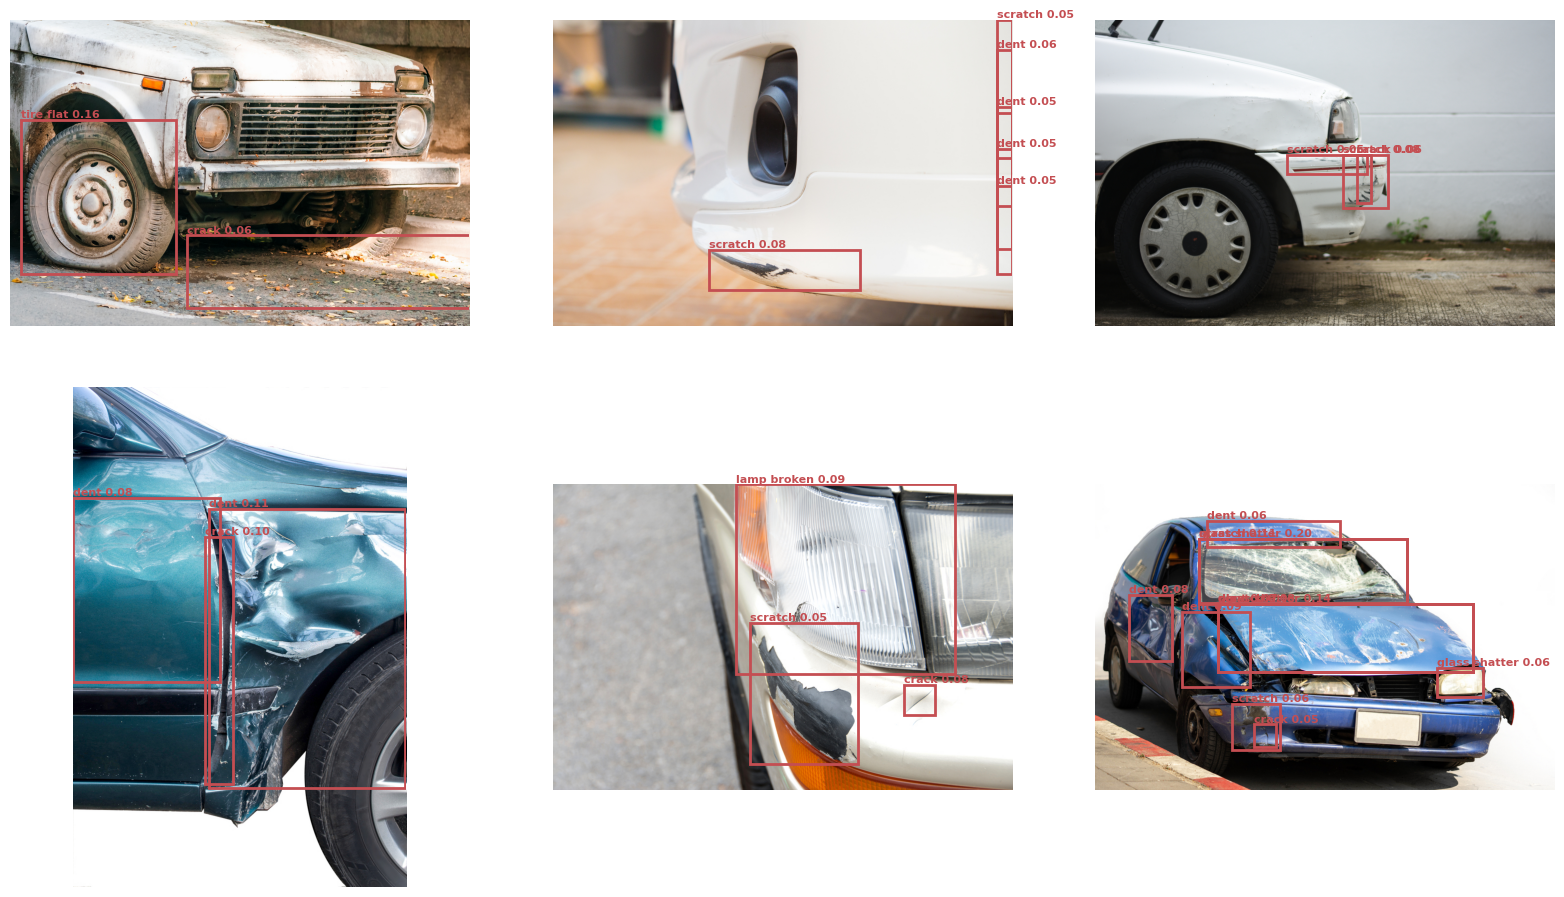

In [53]:
def draw_boxes(ax, image_path, boxes, labels, scores, conf_thr=0.05):
    img = Image.open(image_path)
    w, h = img.size
    ax.imshow(img)
    for box, label, score in zip(boxes, labels, scores):
        if score < conf_thr:
            continue
        x1, y1, x2, y2 = box[0] * w, box[1] * h, box[2] * w, box[3] * h
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="#C44E52", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, f"{CLASS_NAMES[label]} {score:.2f}", color="#C44E52", fontsize=8, weight="bold")
    ax.axis("off")


test_samples = test_image_files[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, fname in zip(axes.flat, test_samples):
    img_path = f"{DATA_DIR}/test/images/{fname}"
    p = test_preds_tta[fname]
    draw_boxes(ax, img_path, p["boxes"], p["labels"], p["scores"], conf_thr=0.05)
plt.tight_layout()
plt.show()

## 10. Скорость инференса

In [51]:
sample_batch = next(iter(test_loader))
pixel_values = sample_batch[0].to(DEVICE)

torch.cuda.synchronize() if DEVICE.type == "cuda" else None
start = time.time()
with torch.no_grad():
    for _ in range(10):
        _ = best_model(pixel_values=pixel_values)
torch.cuda.synchronize() if DEVICE.type == "cuda" else None
elapsed = time.time() - start

inference_ms = (elapsed / 10 / pixel_values.size(0)) * 1000
print(f"Среднее время инференса на изображение: {inference_ms:.2f} мс")

Среднее время инференса на изображение: 22.98 мс


## 11. Сохранение

In [52]:
summary = pd.DataFrame([{
    "model": "RT-DETR-R18 (HF, custom loop)",
    "mAP50_no_tta": map_no_tta["map_50"].item(),
    "mAP50_95_no_tta": map_no_tta["map"].item(),
    "mAP50_tta": map_tta["map_50"].item(),
    "mAP50_95_tta": map_tta["map"].item(),
    "inference_ms": inference_ms,
}])
summary.to_csv("/kaggle/working/rtdetr_summary.csv", index=False)
per_class_ap.to_csv("/kaggle/working/rtdetr_per_class_ap.csv", index=False)

with open("/kaggle/working/rtdetr_val_preds.json", "w") as f:
    json.dump(val_preds_plain, f)
with open("/kaggle/working/rtdetr_test_preds.json", "w") as f:
    json.dump(test_preds_plain, f)

print("Сохранено: чекпоинт (папка rtdetr_r18vd_best), summary, per-class AP, сырые предсказания (БЕЗ TTA) val/test")
summary

Сохранено: чекпоинт (папка rtdetr_r18vd_best), summary, per-class AP, сырые предсказания (БЕЗ TTA) val/test


,model,mAP50_no_tta,mAP50_95_no_tta,mAP50_tta,mAP50_95_tta,inference_ms
0,"RT-DETR-R18 (HF, custom loop)",0.59118,0.469199,0.619976,0.481448,22.975951
